# Beyond Home Runs: What Drives OPS in MLB?

## Research Question

To what extent do home runs, batting average, walks, and strikeouts explain variations in OPS among MLB players?

In [6]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load Data

batting = pd.read_csv(
    "Batting.csv",
    encoding="latin1",
    sep=";"
)

batting.head()

,Rk,Name,Age,Tm,Lg,G,PA,AB,R,H,...,OBP,SLG,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB
0,1,CJ Abrams*,22,WSN,NL,89,340,316,47,82,...,0.306,0.434,0.739,105,137,5,8,3,0,0
1,2,José Abreu,36,HOU,AL,95,400,368,33,90,...,0.293,0.353,0.646,79,130,11,3,0,5,1
2,3,Ronald Acuna Jr.,25,ATL,NL,97,446,391,86,129,...,0.408,0.578,0.986,160,226,7,4,0,2,2
3,4,Willy Adames,27,MIL,NL,89,383,336,44,71,...,0.291,0.411,0.702,90,138,9,3,0,5,0
4,5,Riley Adams,27,WSN,NL,23,87,79,4,22,...,0.337,0.506,0.844,133,40,4,1,1,0,0


In [9]:
# Check Columns

batting.columns

Index(['Rk', 'Name', 'Age', 'Tm', 'Lg', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B',
       'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+',
       'TB', 'GDP', 'HBP', 'SH', 'SF', 'IBB'],
      dtype='object')

In [10]:
batting.columns.tolist()

['Rk',
 'Name',
 'Age',
 'Tm',
 'Lg',
 'G',
 'PA',
 'AB',
 'R',
 'H',
 '2B',
 '3B',
 'HR',
 'RBI',
 'SB',
 'CS',
 'BB',
 'SO',
 'BA',
 'OBP',
 'SLG',
 'OPS',
 'OPS+',
 'TB',
 'GDP',
 'HBP',
 'SH',
 'SF',
 'IBB']

In [11]:
cols = ["HR", "BA", "OBP", "SLG", "OPS"]

batting[cols].head()

,HR,BA,OBP,SLG,OPS
0,10,0.259,0.306,0.434,0.739
1,8,0.245,0.293,0.353,0.646
2,23,0.330,0.408,0.578,0.986
3,17,0.211,0.291,0.411,0.702
4,3,0.278,0.337,0.506,0.844


In [12]:
corr = batting[cols].corr()

corr

,HR,BA,OBP,SLG,OPS
HR,1.000000,0.393300,0.422875,0.605277,0.545476
BA,0.393300,1.000000,0.930338,0.906213,0.945255
OBP,0.422875,0.930338,1.000000,0.876159,0.957385
SLG,0.605277,0.906213,0.876159,1.000000,0.978034
OPS,0.545476,0.945255,0.957385,0.978034,1.000000


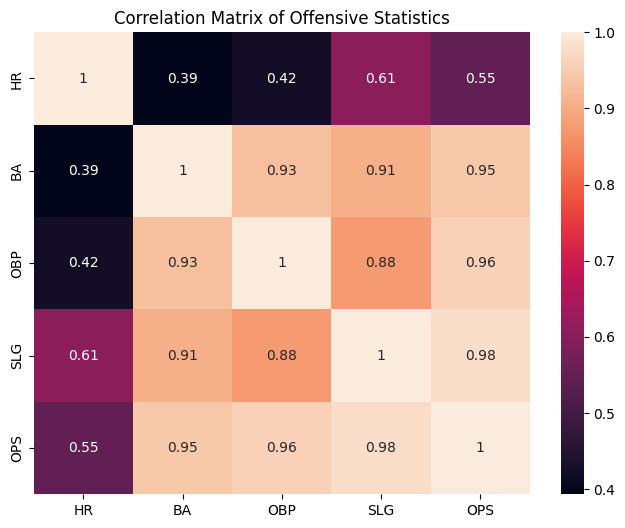

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix of Offensive Statistics")

plt.show()

In [16]:
import statsmodels.api as sm

X = batting[["HR", "BA", "BB", "SO"]]

y = batting["OPS"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    OPS   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     2279.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:02:31   Log-Likelihood:                 790.93
No. Observations:                 695   AIC:                            -1572.
Df Residuals:                     690   BIC:                            -1549.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0641      0.006     10.163      0.0

## Multiple Regression Analysis

A multiple regression model was used to examine how home runs (HR), batting average (BA), walks (BB), and strikeouts (SO) relate to OPS.

The model achieved an R² of 0.93, indicating that these variables explain approximately 93% of the variation in OPS among MLB players.

Batting average was the strongest predictor of OPS, followed by home runs. Walks also had a statistically significant positive relationship with OPS. In contrast, strikeouts were not a significant predictor after controlling for the other variables.

These results suggest that while power hitting contributes to offensive performance, overall hitting ability and plate discipline play a larger role in explaining OPS.

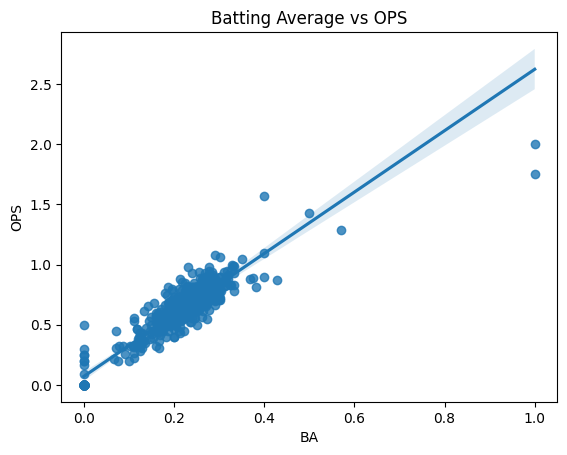

In [17]:
sns.regplot(
    data=batting,
    x="BA",
    y="OPS"
)

plt.title("Batting Average vs OPS")
plt.show()

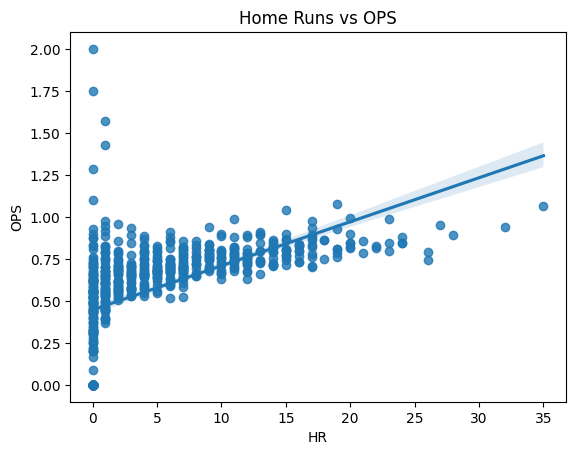

In [18]:
sns.regplot(
    data=batting,
    x="HR",
    y="OPS"
)

plt.title("Home Runs vs OPS")
plt.show()

## Findings

The multiple regression model achieved an R² of 0.93, suggesting that home runs, batting average, walks, and strikeouts explain approximately 93% of the variation in OPS.

Batting average was the strongest predictor of OPS. Home runs also showed a significant positive relationship with OPS, while walks had a smaller but statistically significant effect.

Interestingly, strikeouts were not a significant predictor after controlling for the other variables.

## Conclusion

This analysis investigated which traditional batting statistics best explain OPS among MLB players.

The results suggest that batting average is the most important predictor of OPS, followed by home runs. Walks also contribute positively to offensive performance, while strikeouts alone do not appear to be a strong predictor once other offensive statistics are considered.

These findings highlight that offensive success is not determined solely by power hitting. Consistent hitting ability and plate discipline also play important roles in producing a high OPS.